Class separability (between/within) — PCA: 1.518, LDA: 4.551
Saved figure to: pca_vs_lda.png


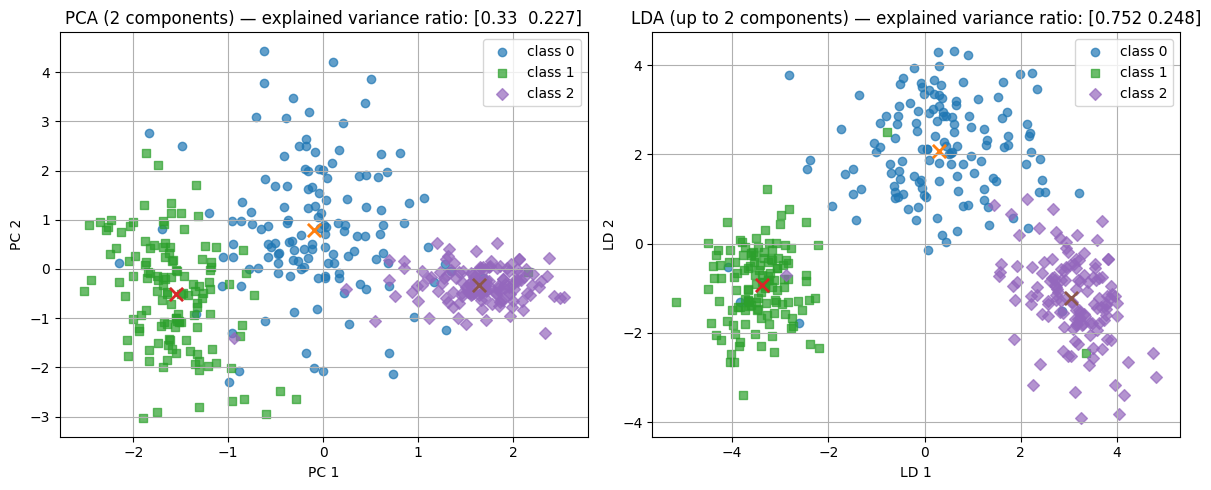

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import pairwise_distances


def make_data(n_samples=300, n_features=5, n_classes=3, random_state=1):
    X, y = make_classification(n_samples=n_samples,
                               n_features=n_features,
                               n_informative=min(n_features, n_features - 1),
                               n_redundant=0,
                               n_clusters_per_class=1,
                               n_classes=n_classes,
                               class_sep=1.5,
                               flip_y=0.01,
                               random_state=random_state)
    return X, y


def fit_and_project(X, y, n_components=2):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    pca = PCA(n_components=n_components, random_state=0)
    X_pca = pca.fit_transform(Xs)

    # LDA max components = n_classes - 1
    n_classes = np.unique(y).size
    lda_n_comp = min(n_components, max(1, n_classes - 1))
    lda = LinearDiscriminantAnalysis(n_components=lda_n_comp)
    X_lda = lda.fit_transform(Xs, y)

    # In some edge cases (e.g. lda_n_comp == 1) make both arrays 2D for plotting
    if X_lda.shape[1] == 1:
        # add a zero column for the 2nd axis so we can plot side-by-side in 2D
        X_lda = np.hstack([X_lda, np.zeros((X_lda.shape[0], 1))])

    if X_pca.shape[1] == 1:
        X_pca = np.hstack([X_pca, np.zeros((X_pca.shape[0], 1))])

    return scaler, pca, lda, Xs, X_pca, X_lda


def plot_comparison(X_pca, X_lda, y, pca, lda, outpath="pca_vs_lda.png"):
    classes = np.unique(y)
    markers = ['o', 's', 'D', '^', 'v', 'P', 'X']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # PCA plot
    ax = axes[0]
    for i, cls in enumerate(classes):
        sel = y == cls
        ax.scatter(X_pca[sel, 0], X_pca[sel, 1], label=f'class {cls}', marker=markers[i % len(markers)], alpha=0.7)
        # centroid
        cx, cy = X_pca[sel].mean(axis=0)
        ax.scatter(cx, cy, marker='x', s=90, linewidths=2)
    ax.set_title(f'PCA (2 components) — explained variance ratio: {np.round(pca.explained_variance_ratio_[:2], 3)}')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.legend(loc='best')
    ax.grid(True)

    # LDA plot
    ax = axes[1]
    for i, cls in enumerate(classes):
        sel = y == cls
        ax.scatter(X_lda[sel, 0], X_lda[sel, 1], label=f'class {cls}', marker=markers[i % len(markers)], alpha=0.7)
        cx, cy = X_lda[sel].mean(axis=0)
        ax.scatter(cx, cy, marker='x', s=90, linewidths=2)
    # LDA explained variance ratio attribute may exist; handle gracefully
    lda_ev = getattr(lda, 'explained_variance_ratio_', None)
    if lda_ev is not None:
        lda_ev_str = np.round(lda_ev[:min(2, lda_ev.size)], 3)
    else:
        lda_ev_str = 'N/A'

    ax.set_title(f'LDA (up to 2 components) — explained variance ratio: {lda_ev_str}')
    ax.set_xlabel('LD 1')
    ax.set_ylabel('LD 2')
    ax.legend(loc='best')
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    print(f"Saved figure to: {outpath}")
    plt.show()


def compute_class_separation(X_proj, y):
    """A simple class separability metric: ratio of between-class scatter to within-class scatter."""
    classes = np.unique(y)
    overall_mean = X_proj.mean(axis=0)
    Sb = 0.0
    Sw = 0.0
    for cls in classes:
        Xi = X_proj[y == cls]
        ni = Xi.shape[0]
        mean_i = Xi.mean(axis=0)
        Sb += ni * np.sum((mean_i - overall_mean) ** 2)
        Sw += np.sum((Xi - mean_i) ** 2)
    # to avoid division by zero
    if Sw == 0:
        return np.inf
    return Sb / Sw


def main():
    X, y = make_data(n_samples=400, n_features=6, n_classes=3, random_state=2)
    scaler, pca, lda, Xs, X_pca, X_lda = fit_and_project(X, y, n_components=2)

    # compute and print separability metrics
    sep_pca = compute_class_separation(X_pca, y)
    sep_lda = compute_class_separation(X_lda, y)

    print(f"Class separability (between/within) — PCA: {sep_pca:.3f}, LDA: {sep_lda:.3f}")

    plot_comparison(X_pca, X_lda, y, pca, lda)


if __name__ == '__main__':
    main()


https://shad.io/MatVis

2D to 1D
